# Longitudinal boundary-condition comparison with a Harris pulse

This notebook characterizes Wakis' longitudinal (`z-`, `z+`) PEC, PML, CPML, and periodic boundary conditions. A planar transverse `Ex` Harris pulse propagates in both longitudinal directions. The transverse boundaries are periodic so that the experiment isolates the longitudinal boundary behavior.

The expected qualitative behavior is:

- **PEC:** the pulse reflects with approximately unit magnitude and reversed electric-field sign.
- **PML/CPML:** the outgoing pulse is absorbed with little reflected field.
- **Periodic:** the pulse leaving one longitudinal face re-enters through the opposite face.

In [1]:
import sys

import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm

sys.path.append("../")

from wakis.gridFIT3D import GridFIT3D
from wakis.solverFIT3D import SolverFIT3D
from wakis.sources import Pulse

## Simulation configuration

The physical domain is long in `z`. The source and probe are placed near the low face so that the PEC reflection arrives early, while the periodic return crosses nearly the full domain before reaching the probe.

In [2]:
Nx = Ny = 8
Nz = 200

xmin, xmax = -0.025, 0.025
ymin, ymax = -0.025, 0.025
zmin, zmax = 0.0, 0.5

dt = 2.5e-12
Nt = 1200
pulse_length = 0.15
source_k = 50
probe_k = 20
n_pml = 10

time = np.arange(Nt) * dt

boundary_cases = {
    "PEC": {"boundary": "pec"},
    "PML": {"boundary": "pml", "n_pml": n_pml},
    "CPML": {
        "boundary": "cpml",
        "n_pml": n_pml,
        "kappa_max": 5,
        "alpha_max": 0.05,
        "pml_exp": 4,
        "sigma_factor": 1.0,
    },
    "Periodic": {"boundary": "periodic"},
}

colors = {
    "Reference": "black",
    "PEC": "tab:blue",
    "PML": "tab:orange",
    "CPML": "tab:green",
    "Periodic": "tab:red",
}

## Boundary-case runner

Each case uses the same grid, source, timestep, and probe. Besides the probe trace, the complete centerline is retained at every timestep for a `z-t` propagation map.

In [3]:
def run_harris_case(name, case):
    grid = GridFIT3D(xmin, xmax, ymin, ymax, zmin, zmax, Nx, Ny, Nz, verbose=0)
    longitudinal_bc = case["boundary"]
    bc_low = ["periodic", "periodic", longitudinal_bc]
    bc_high = ["periodic", "periodic", longitudinal_bc]
    solver_kwargs = {key: value for key, value in case.items() if key != "boundary"}

    solver = SolverFIT3D(
        grid,
        bc_low=bc_low,
        bc_high=bc_high,
        dt=dt,
        verbose=0,
        **solver_kwargs,
    )
    source = Pulse(
        field="Ex",
        xs=slice(0, Nx),
        ys=slice(0, Ny),
        zs=source_k,
        shape="harris",
        L=pulse_length,
    )

    probe = np.zeros(Nt)
    history = np.zeros((Nt, Nz))
    for n in tqdm(range(Nt), desc=name, leave=False):
        source.update(solver, n * solver.dt)
        solver.one_step()
        probe[n] = solver.E[Nx // 2, Ny // 2, probe_k, "x"]
        history[n] = solver.E[Nx // 2, Ny // 2, :, "x"]

    return {
        "probe": probe,
        "history": history,
        "z": solver.z.copy(),
        "dt": float(solver.dt),
    }


results = {name: run_harris_case(name, case) for name, case in boundary_cases.items()}

Generating grid with 12800 mesh cells...
Initializing Electromagnetic solver...


PEC:   0%|          | 0/1200 [00:00<?, ?it/s]

Generating grid with 12800 mesh cells...
Initializing Electromagnetic solver...


PML:   0%|          | 0/1200 [00:00<?, ?it/s]

Generating grid with 12800 mesh cells...
Initializing Electromagnetic solver...
[!] CPML requires Total-Field/Scattered-Field injection, setting source_type='tfsf'


CPML:   0%|          | 0/1200 [00:00<?, ?it/s]

Generating grid with 12800 mesh cells...
Initializing Electromagnetic solver...


Periodic:   0%|          | 0/1200 [00:00<?, ?it/s]

## Extended-domain incident reference

The reference grid has the same cell sizes but is extended far beyond both ends of the comparison domain. Its PEC reflections cannot return to the probe during the simulated time, so its probe trace represents the incident field. This avoids constructing a zero-cell CPML reference.

In [4]:
reference_zmin, reference_zmax = -0.5, 1.0
reference_Nz = 600
reference_source_k = source_k + 200
reference_probe_k = probe_k + 200

reference_grid = GridFIT3D(
    xmin,
    xmax,
    ymin,
    ymax,
    reference_zmin,
    reference_zmax,
    Nx,
    Ny,
    reference_Nz,
    verbose=0,
)
reference_solver = SolverFIT3D(
    reference_grid,
    bc_low=["periodic", "periodic", "pec"],
    bc_high=["periodic", "periodic", "pec"],
    dt=dt,
    verbose=0,
)
reference_source = Pulse(
    field="Ex",
    xs=slice(0, Nx),
    ys=slice(0, Ny),
    zs=reference_source_k,
    shape="harris",
    L=pulse_length,
)

reference_probe = np.zeros(Nt)
for n in tqdm(range(Nt), desc="Reference", leave=False):
    reference_source.update(reference_solver, n * reference_solver.dt)
    reference_solver.one_step()
    reference_probe[n] = reference_solver.E[Nx // 2, Ny // 2, reference_probe_k, "x"]

Generating grid with 38400 mesh cells...
Initializing Electromagnetic solver...


Reference:   0%|          | 0/1200 [00:00<?, ?it/s]

## Time-domain probe comparison

The first pulse at the probe is the common incident field. Later activity identifies the boundary response: an early sign-reversed return for PEC, small residuals for the absorbers, and a delayed re-entry for the periodic case.

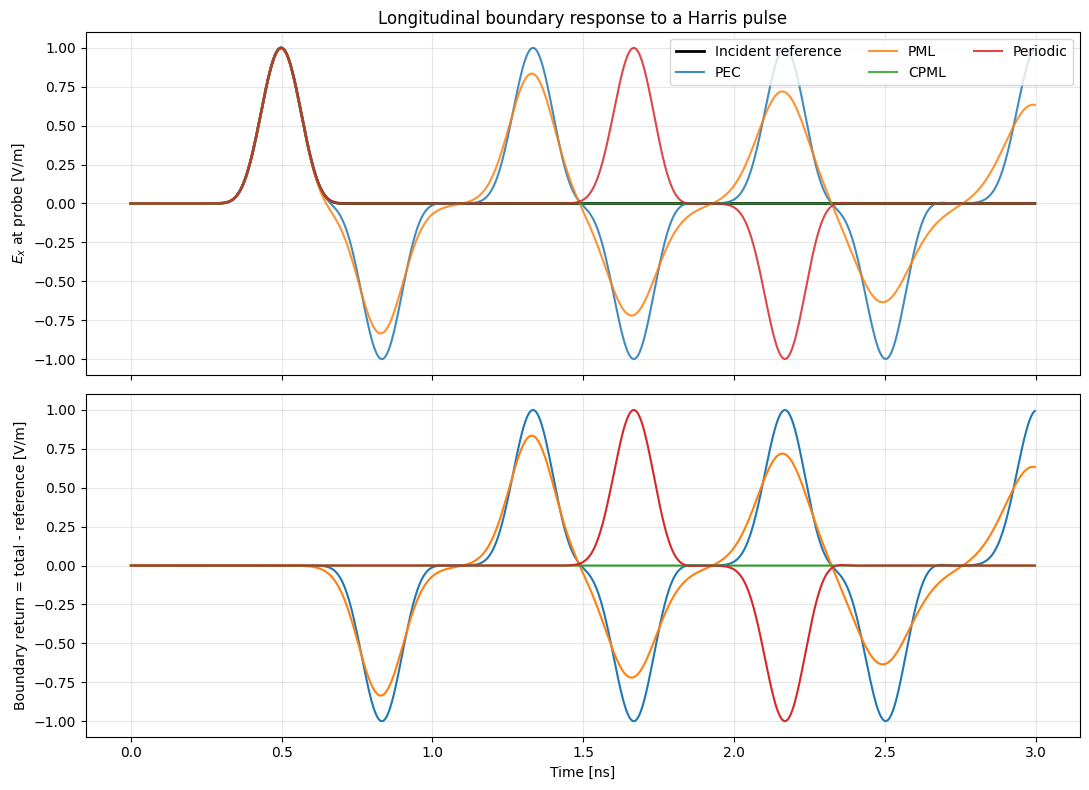

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
axes[0].plot(
    time * 1e9,
    reference_probe,
    color=colors["Reference"],
    label="Incident reference",
    linewidth=2,
)
for name, result in results.items():
    axes[0].plot(
        time * 1e9, result["probe"], color=colors[name], label=name, alpha=0.85
    )
    axes[1].plot(
        time * 1e9,
        result["probe"] - reference_probe,
        color=colors[name],
        label=name,
    )

axes[0].set_ylabel(r"$E_x$ at probe [V/m]")
axes[0].set_title("Longitudinal boundary response to a Harris pulse")
axes[0].legend(ncol=3)
axes[1].set_xlabel("Time [ns]")
axes[1].set_ylabel("Boundary return = total - reference [V/m]")
for ax in axes:
    ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Longitudinal propagation maps

These maps make the boundary mechanism visible across the whole domain. The source plane is marked in black. Dashed gray lines mark the inner edges of absorbing layers in the PML and CPML panels.

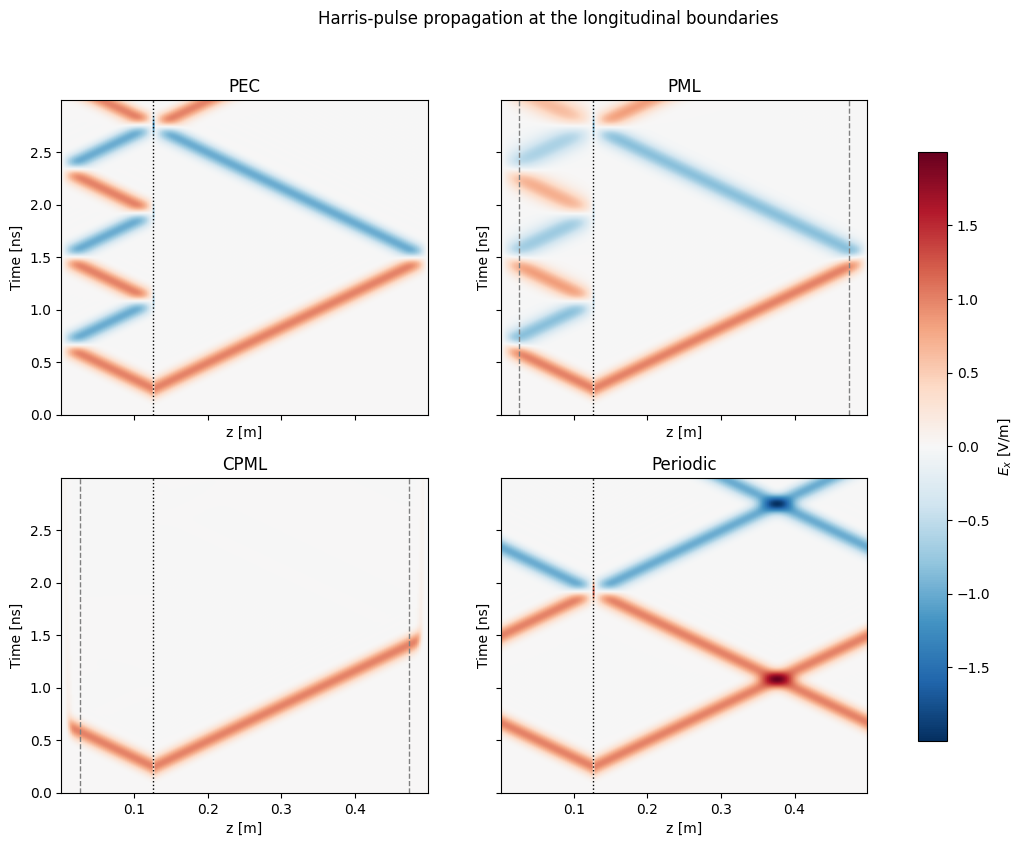

In [6]:
field_limit = max(np.abs(result["history"]).max() for result in results.values())
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True, sharey=True)
for ax, (name, result) in zip(axes.flat, results.items()):
    image = ax.imshow(
        result["history"],
        origin="lower",
        aspect="auto",
        extent=[result["z"][0], result["z"][-1], time[0] * 1e9, time[-1] * 1e9],
        cmap="RdBu_r",
        vmin=-field_limit,
        vmax=field_limit,
    )
    ax.axvline(result["z"][source_k], color="black", linestyle=":", linewidth=1)
    if name in ("PML", "CPML"):
        ax.axvline(result["z"][n_pml], color="gray", linestyle="--", linewidth=1)
        ax.axvline(result["z"][-n_pml - 1], color="gray", linestyle="--", linewidth=1)
    ax.set_title(name)
    ax.set_xlabel("z [m]")
    ax.set_ylabel("Time [ns]")

fig.colorbar(image, ax=axes, label=r"$E_x$ [V/m]", shrink=0.85)
fig.suptitle("Harris-pulse propagation at the longitudinal boundaries", y=0.98)
plt.show()

## Spectral boundary-return estimate

The residual spectrum is the Fourier transform of `total - incident reference`, normalized by the incident power spectrum where the incident signal is sufficiently resolved. For PML and CPML this estimates reflection. For PEC and periodic boundaries it measures the expected returned pulse rather than absorption quality.

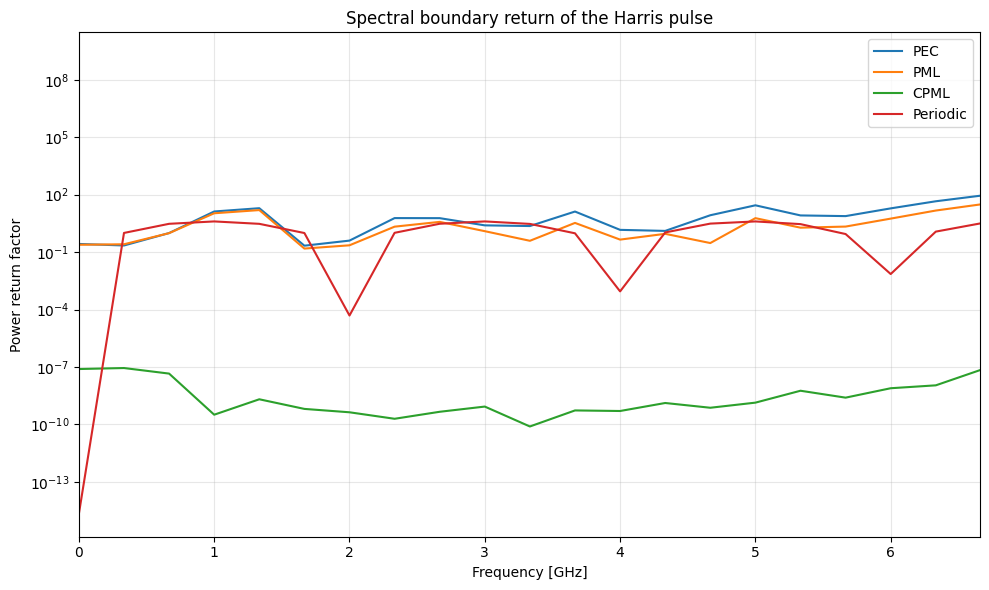

In [7]:
frequency = np.fft.rfftfreq(Nt, dt)
incident_spectrum = np.fft.rfft(reference_probe)
resolved = np.abs(incident_spectrum) > 1e-6 * np.abs(incident_spectrum).max()

fig, ax = plt.subplots(figsize=(10, 6))
for name, result in results.items():
    residual_spectrum = np.fft.rfft(result["probe"] - reference_probe)
    return_factor = np.full_like(frequency, np.nan, dtype=float)
    return_factor[resolved] = (
        np.abs(residual_spectrum[resolved]) / np.abs(incident_spectrum[resolved])
    ) ** 2
    ax.plot(frequency * 1e-9, return_factor, color=colors[name], label=name)

ax.set(
    xlabel="Frequency [GHz]",
    ylabel="Power return factor",
    title="Spectral boundary return of the Harris pulse",
    xlim=(0, 6.66),
)
ax.set_yscale("log")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

## Diagnostic return amplitudes

These peak residuals are aids for comparing runs, not acceptance tolerances. The early window contains the low-face reflection; the later window contains periodic wrap-around and eventually the high-face response.

In [8]:
diagnostic_windows = {
    "early low-face return": (0.55e-9, 1.25e-9),
    "late / periodic return": (1.30e-9, 2.90e-9),
}

print(f"Incident peak at probe: {np.abs(reference_probe).max():.6e} V/m")
for label, (start, stop) in diagnostic_windows.items():
    window = (time >= start) & (time < stop)
    print(f"\n{label} ({start * 1e9:.2f}-{stop * 1e9:.2f} ns)")
    for name, result in results.items():
        residual = result["probe"] - reference_probe
        window_indices = np.flatnonzero(window)
        peak_n = window_indices[np.abs(residual[window]).argmax()]
        print(
            f"  {name:8s}: {residual[peak_n]:+.6e} V/m at {time[peak_n] * 1e9:.3f} ns"
        )

Incident peak at probe: 9.999209e-01 V/m

early low-face return (0.55-1.25 ns)
  PEC     : -9.999449e-01 V/m at 0.833 ns
  PML     : -8.352790e-01 V/m at 0.828 ns
  CPML    : -5.644950e-06 V/m at 0.905 ns
  Periodic: +1.096492e-13 V/m at 1.247 ns

late / periodic return (1.30-2.90 ns)
  PEC     : -9.996813e-01 V/m at 1.667 ns
  PML     : +8.347336e-01 V/m at 1.330 ns
  CPML    : -6.596608e-05 V/m at 2.558 ns
  Periodic: +9.996798e-01 V/m at 1.667 ns
